# UC Berkeley Capstone Project -- Data Analysis & Modelling

This is a notebook for my UC Berkeley Capstone project.

I have a harvester script running in GCP that collects YouTube video metadata and metrics and stores that in a BQ table. 
Because the script is running in an ongoing basis, and I have limited time before I need to turn in the project, I am going to start working with synthetic data integrated with my real data, and gradually shift over to all real data.

- This will allow me start modelling sooner. 
- The synthetic data will be identifiable in the DataFrame.
- I will be storing a Parquet snapshot of the BQ data extract + model version in a GCS Bucket, so that I can always see which specific data + model produced which specific results.

The workflow here is:

1. Create a snapshot of the BQ data 
1. Add the synthetic data rows
1. Store the dataset in a versioned GCS bucket
1. (when modelling) store model vesrion data + stats in a versioned GCS bucket as well.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.snapshot_data as snapshot

from data_processing.data_cleanup import build_clean_dataset
from data_processing.feature_engineering import engineer_features
from data_processing.synthetic_data import generate_synthetic_data, combine_real_and_synthetic

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    RocCurveDisplay,
)


In [2]:
def create_new_snapshot(
    df: pd.DataFrame, version_name: str, additional_notes: str = ""
):
    """
    Creates snapshots in GCS bucket for:
      - Channel baseline data
      - Channel median data
      - Video snapshot data

    Snapshots can be viewed via `snapshot.list_snapshots` and loaded via
    `snapshot.load_videos` and `snapshot.load_baselines`

    df: DataFrame to snapshot.
    version_name: Name like 'v1.0_real'
    additional_notes: Descriptive notes. `version_name` is automatically added.

    Returns: A tuple of video and baseline metadata objects.
    """
    video_meta = snapshot.save_snapshot(
        df=df,
        version_tag=version_name,
        notes=f"Creating {version_name} video snapshot. {additional_notes}",
    )
    _, _, baseline_meta = snapshot.snapshot_baselines(
        version_name,
        notes=f"Channel baselines corresponding to {version_name} video snapshot",
    )
    return (video_meta, baseline_meta)


# Only run this when creating new versions
# new_version_name = "vM.m_real"
# additional_notes = ""
# video_meta, baseline_meta = create_new_snapshot(new_version_name, additional_notes=additional_notes)

In [3]:
# See what's available
snapshot.list_snapshots()

Found 4 snapshots:

  [baselines] v1.0_model_mixed66  |  28544 baseline videos, 965 medians  |  2026-03-25
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_model_mixed66_28544rows_20260325_035026.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_model_mixed66_965rows_20260325_035026.parquet

  [baselines] v1.0_real  |  28544 baseline videos, 965 medians  |  2026-03-22
              Files: gs://maduros-dolce-capstone-data/snapshots/baselines_v1.0_real_28544rows_20260322_184459.parquet
                     gs://maduros-dolce-capstone-data/snapshots/medians_v1.0_real_965rows_20260322_184459.parquet

  [videos]    v1.0_model_mixed66  |  7625 rows  |  2026-03-25
              Polls: {}
              File:  gs://maduros-dolce-capstone-data/snapshots/snapshots_v1.0_model_mixed66_7625rows_20260325_035024.parquet

  [videos]    v1.0_real  |  12990 rows  |  2026-03-22
              Polls: {'upload': 5322, '24h': 5041, '7d': 2627}
 

In [4]:
# Load an existing snapshot (no new version created)
CURRENT_VERSION = "v1.0_real"
df_videos, meta = snapshot.load_videos(CURRENT_VERSION)
df_baselines, df_medians, baseline_meta = snapshot.load_baselines(CURRENT_VERSION)

print(f"Video snapshots: {len(df_videos)}")
print(f"Baseline videos: {len(df_baselines)}")
print(f"Baseline medians: {len(df_medians)}")

df_videos.head()

Loaded snapshot 'v1.0_real': 12990 rows from 2026-03-22
  Polls: {'upload': 5322, '24h': 5041, '7d': 2627}
Loaded baselines 'v1.0_real': 28544 baseline videos, 965 median rows (965 channels)
Video snapshots: 12990
Baseline videos: 28544
Baseline medians: 965


,video_id,poll_timestamp,channel_id,channel_handle,title,view_count,like_count,comment_count,face_count,brightness,...,description,tags,duration_seconds,category_id,category_name,published_at,poll_label,hours_since_publish,subscriber_count,contains_synthetic_media
0,n3BeLZHjszE,2026-03-22 10:05:19.229224+00:00,UCJ8clxRNNMOF-1KaRFVaLlQ,@aqibtechreview134,Samsung Galaxy S27 Ultra Official Trailer & OF...,27,1,0,0,59.873854,...,The Future is Here: Samsung Galaxy S27 Ultra O...,"[Samsung Galaxy S27 Ultra, Galaxy S27 Ultra Le...",654,28,Science & Technology,2026-03-22 06:44:57+00:00,upload,3.34,1610,False
1,-zFOL2-QpPM,2026-03-22 10:05:19.229224+00:00,UCJ8clxRNNMOF-1KaRFVaLlQ,@aqibtechreview134,"DJI Mini 6 Pro Official Leaks: 1-Inch Sensor, ...",3,0,0,0,51.670718,...,🚀 DJI Mini 6 Pro: The Future of Drone Technolo...,"[DJI Mini 6 Pro, Mini 6 Pro Leaks, DJI Mini 6 ...",706,28,Science & Technology,2026-03-22 05:40:56+00:00,upload,4.41,1610,False
2,DBwp3mPn-VQ,2026-03-22 10:05:19.229224+00:00,UCJ8clxRNNMOF-1KaRFVaLlQ,@aqibtechreview134,"Apple TV 2026: A18 Bionic, 8K Gaming & The $99...",8,0,0,0,62.892558,...,The living room war is officially over! Apple ...,"[Apple TV 2026 redesign, new Apple TV 4K 2026 ...",681,28,Science & Technology,2026-03-22 04:42:47+00:00,upload,5.38,1610,False
3,4sikDye-XP0,2026-03-22 10:05:19.229224+00:00,UCTMd_rwB7b3RZM6o6wc-KkQ,@bhavanashealthycooking,Indori Poha Ki Recipe. इंदौर के पोहा कैसे बना...,1621,22,0,1,45.844051,...,,[],1570,28,Science & Technology,2026-03-22 06:07:50+00:00,upload,3.96,1490,False
4,iovDZ-GNeyo,2026-03-22 10:05:19.229224+00:00,UCfUoif9Pj1fA-Yy2yqFRQpQ,@parivlog-bihar,मम्मा कि बिटिया को भुखु लगी है | New Vlog | Vl...,883,0,0,0,88.155376,...,मम्मा कि बिटिया को भुखु लगी है | New Vlog | Vl...,"[Pari Vlog, Pari Life Style, Vlog Video, Daily...",64,22,People & Blogs,2026-03-22 06:33:45+00:00,upload,3.53,199000,False


In [5]:
df_baselines.head()

,channel_id,channel_handle,vertical,tier,video_id,title,published_at,duration_seconds,category_id,category_name,view_count,like_count,comment_count,subscriber_count,baseline_polled_at
0,UCWv7vMbMWH4-V0ZXdmDpPBA,@programmingwithmosh,Tech,L,hwQyfTmxt9I,New Course Dropping Soon...,2026-03-19 13:01:20+00:00,118,27,Education,26045,765,18,5000000,2026-03-21 04:01:26.898059+00:00
1,UCWv7vMbMWH4-V0ZXdmDpPBA,@programmingwithmosh,Tech,L,-vqGZaThouQ,New Course Dropping Soon...,2026-03-18 13:00:01+00:00,118,27,Education,20144,1199,103,5000000,2026-03-21 04:01:26.898059+00:00
2,UCWv7vMbMWH4-V0ZXdmDpPBA,@programmingwithmosh,Tech,L,CIXT-kc3l6g,Top Programming Languages to Learn in 2026 #ai...,2025-12-19 13:30:17+00:00,170,27,Education,42203,1062,27,5000000,2026-03-21 04:01:26.898059+00:00
3,UCWv7vMbMWH4-V0ZXdmDpPBA,@programmingwithmosh,Tech,L,naNcmnKskUE,Top 5 Programming Languages to Learn in 2026 (...,2025-12-18 13:00:06+00:00,691,27,Education,257089,7710,732,5000000,2026-03-21 04:01:26.898059+00:00
4,UCWv7vMbMWH4-V0ZXdmDpPBA,@programmingwithmosh,Tech,L,bshe96X5KkA,AI Course for Developers - Build AI-Powered Apps,2025-08-26 12:30:47+00:00,66,27,Education,26634,859,13,5000000,2026-03-21 04:01:26.898059+00:00


In [6]:
df_medians.head()

,channel_id,channel_handle,baseline_video_count,median_views,median_likes,median_comments,median_engagement_rate
0,UCWv7vMbMWH4-V0ZXdmDpPBA,@programmingwithmosh,30,97045,3738,163,0.030574
1,UCFbNIlppjAuEX4znoulh0Cw,@webdevsimplified,30,38984,1504,60,0.037358
2,UCLKZ20yD2tNMBOkSDZo4FeQ,@shanehummus,30,5094,286,39,0.059637
3,UC2Zs9v2hL2qZZ7vsAENsg4w,@justinsung,30,92628,4154,224,0.043158
4,UCZ4AMrDcNrfy3X6nsU8-rPg,@economicsexplained,30,463941,12496,1412,0.030341


In [7]:
print(df_videos.describe())

print(df_videos.info())

          view_count   like_count  comment_count  face_count    brightness  \
count        12990.0      12990.0        12990.0     12990.0  12990.000000   
mean    34021.219861  1227.828253      63.344958    0.837028     76.848276   
std    323371.786035  6341.310058     282.284115    1.007096     28.045903   
min              0.0          0.0            0.0         0.0      0.000000   
25%            241.0         10.0            0.0         0.0     58.422690   
50%           1462.0         68.0            4.0         1.0     74.795700   
75%          9286.25        425.0           25.0         1.0     92.240245   
max       25826937.0     304343.0         9608.0        14.0    212.109184   

       colorfulness  duration_seconds  hours_since_publish  subscriber_count  
count  12990.000000           12990.0         12990.000000           12990.0  
mean      42.168769       1074.778984            41.332661    1469237.938414  
std       23.492837       2504.765361            74.938334  

In [8]:
# Initial cleaning

# NULL value in contains_synthetic_media means that the video couldn't be asssessed (e.g. private or deleted).
# execlude those
df_videos.dropna(subset=["contains_synthetic_media"], inplace=True)

# Build the df with baseline metrics inlined 
df_clean = build_clean_dataset(df_videos, df_medians)
df_model = engineer_features(df_clean)

print(df_model.head())

Building clean dataset

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 2562 (dropped 2677 incomplete)
  Pivoted shape: (2625, 34)

[2/3] Joining baseline medians...
  Baseline join: 2625/2625 videos matched a channel median

[3/3] Cleaning data...
  Cleaned: 2625 rows × 40 columns

Clean dataset: 2625 rows × 40 columns
Engineering features

[1/7] Computing target variable...
  Target distribution: 56.5% above baseline, 43.5% below

[2/7] Computing velocity features...
  Computed velocity for: ['view_count', 'like_count', 'comment_count', 'subscriber_count']

[3/7] Computing subscriber-normalized metrics...
  Computed subscriber-normalized metrics for upload/24h/7d

[4/7] Computing categorical features...
  Title categories:
title_category
neutral        1708
all_caps        262
exclamation     259
question        237
listicle         85
how_to           38
clickbait        30
emoji_heavy       6
  Description categories:
desc_category
link_heavy        719
has_links         630

In [9]:

# Generate synthetic rows (baselines from real channels)
df_synth = generate_synthetic_data(df_model, num_rows=5000, seed=42)

# Combine
df_combined = combine_real_and_synthetic(df_model, df_synth)

df_combined.head()

Generating 5000 synthetic rows

[1/5] Preparing data for synthesis...
  Input shape: (2625, 22)

[2/5] Fitting GaussianCopulaSynthesizer...


/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


  Fit complete

[3/5] Sampling synthetic rows...
  Generated 5000 rows

[4/5] Assigning real channels and baselines...
  Assigned 5000 synthetic rows to 474 real channels
  Baseline match: 5000/5000

[5/5] Postprocessing and recomputing features...

Synthetic data: 5000 rows
Assigned to 474 real channels
Target balance: {1: 2752, 0: 2248}
Combined dataset: 7625 rows (2625 real + 5000 synthetic, 66% synthetic)


/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/data_processing/synthetic_data.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(
/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/data_processing/synthetic_data.py:350: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(


,video_id,channel_id,channel_handle,title,description,tags,duration_seconds,category_id,category_name,published_at,...,desc_link_count,desc_hashtag_count,tag_count,has_tags,publish_hour,publish_dayofweek,publish_is_weekend,is_short,duration_minutes,contains_synthetic_data
0,USpU40M7iJM,UCnfJ-NeOvfuA9fuIZUmA2UA,@-journal,"7,000 Year Old Human Skull Found In Remarkable...",A construction worker is clearing a path throu...,[],2822,24,Entertainment,2026-03-10 19:00:26+00:00,...,1,0,0,0,19,1,0,0,47.033333,False
1,sxqRMYON9u8,UCnfJ-NeOvfuA9fuIZUmA2UA,@-journal,Girl Searches for Her Family’s Ancestry After ...,"After the passing of her mother, a young woman...",[],978,24,Entertainment,2026-03-06 19:00:55+00:00,...,2,0,0,0,19,4,0,0,16.3,False
2,aMV_K0LwNR0,UCnfJ-NeOvfuA9fuIZUmA2UA,@-journal,Historian Unveals Scandalous Affair In Woman's...,When a historian uncovers a long-buried scanda...,[],614,24,Entertainment,2026-03-13 19:00:00+00:00,...,1,0,0,0,19,4,0,0,10.233333,False
3,LmFCvzc9NCE,UCWJedqvdP2gB2f3qaJCO05g,@91mobiles,This Gaming Setup makes me go HYPER!!!,This gaming setup features the HyperX SoloCast...,[],75,28,Science & Technology,2026-03-09 12:38:56+00:00,...,6,7,0,0,12,0,0,0,1.25,False
4,Hxg1EJ7jCLo,UCvzTJH6G9bH5nCQ1Hfb8nGg,@9algames,CAN I REACH DIVISION 1 USING A FULL PLAYERS O...,Get urself quality football jerseys at low pri...,[],1421,20,Gaming,2026-03-11 07:56:36+00:00,...,5,5,0,0,7,2,0,0,23.683333,False


In [19]:
# Only need to run when there is new base data to snapshot
#video_combined_meta, baseline_combined_meta = create_new_snapshot(
#    df_combined,
#    "v1.0_model_mixed66",
#    additional_notes="2625 real + 5000 synthetic (GaussianCopula seed=42), real channel baselines",
#)

df_combined, _ = snapshot.load_videos("v1.0_model_mixed66")
df_train = df_combined

# never evaluate on synthetic data):
df_eval = df_combined[~df_combined["contains_synthetic_data"]]

df_train.sample(5)

Loaded snapshot 'v1.0_model_mixed66': 7625 rows from 2026-03-25
  Polls: {}


,video_id,channel_id,channel_handle,title,description,tags,duration_seconds,category_id,category_name,published_at,...,desc_link_count,desc_hashtag_count,tag_count,has_tags,publish_hour,publish_dayofweek,publish_is_weekend,is_short,duration_minutes,contains_synthetic_data
5753,syn-003128,UC6bcPazOrKt_dbqqE7loC7w,@mystical-philosophy,[Synthetic],[Synthetic],[],16,27,Synthetic,NaT,...,0,0,0,0,0,0,0,1,0.266667,True
7434,syn-004809,UCLM2cAfUUTDDqg8ms2hodyQ,@happyaujla,[Synthetic],[Synthetic],[],1774,27,Synthetic,NaT,...,0,0,0,0,0,0,0,0,29.566667,True
6497,syn-003872,UCKL-_atE_2N0aHkY5KDegDQ,@wilkoylottovlog6123,[Synthetic],[Synthetic],[],414,28,Synthetic,NaT,...,0,0,0,0,0,0,0,0,6.9,True
3445,syn-000820,UCVvwbez-BNlWvbxtpOx0MGQ,@historyla,[Synthetic],[Synthetic],[],602,27,Synthetic,NaT,...,0,0,0,0,0,0,0,0,10.033333,True
6868,syn-004243,UC9ESQKs98jVWjjUEWkvTMvA,@wscubecybersecurity,[Synthetic],[Synthetic],[],872,24,Synthetic,NaT,...,0,0,0,0,0,0,0,0,14.533333,True


In [ ]:
# --- Define feature columns (exclude IDs, text, timestamps, target, metadata) ---

# Add 7d metric columns to the exclusion list
EXCLUDE_7D = [c for c in df_combined.columns if c.endswith('_7d')]
print(f"Excluding 7d features: {EXCLUDE_7D}")

EXCLUDE_COLS = [
    # IDs and text
    'video_id', 'channel_id', 'channel_handle', 'title', 'description', 'tags',
    'category_id', 'category_name',
    # Timestamps
    'published_at', 'poll_timestamp_upload', 'poll_timestamp_24h', 'poll_timestamp_7d',
    # Target and intermediate
    'above_baseline', 'engagement_7d', 'baseline_engagement',
    # Metadata flags
    'contains_synthetic_data', 'contains_synthetic_media',
    # Baseline raw (already captured in baseline_engagement)
    'baseline_channel_handle', 'baseline_video_count',
    'baseline_median_views', 'baseline_median_likes',
    'baseline_median_comments', 'baseline_median_engagement_rate',
    # Categorical groupings (use the encoded versions instead)
    'vertical', 'tier',
]

EXCLUDE_COLS.extend(EXCLUDE_7D)

feature_cols = [c for c in df_combined.columns if c not in EXCLUDE_COLS]
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)


Excluding 7d features: ['view_count_7d', 'like_count_7d', 'comment_count_7d', 'subscriber_count_7d', 'hours_since_publish_7d', 'poll_timestamp_7d', 'engagement_7d', 'views_per_sub_7d', 'likes_per_sub_7d', 'comments_per_sub_7d']

Feature columns (39):
['duration_seconds', 'face_count', 'brightness', 'colorfulness', 'view_count_upload', 'like_count_upload', 'comment_count_upload', 'subscriber_count_upload', 'hours_since_publish_upload', 'view_count_24h', 'like_count_24h', 'comment_count_24h', 'subscriber_count_24h', 'hours_since_publish_24h', 'baseline_baseline_video_count', 'view_count_velocity_24h', 'like_count_velocity_24h', 'comment_count_velocity_24h', 'subscriber_count_velocity_24h', 'views_per_sub_upload', 'likes_per_sub_upload', 'comments_per_sub_upload', 'views_per_sub_24h', 'likes_per_sub_24h', 'comments_per_sub_24h', 'title_category', 'desc_category', 'title_length', 'title_word_count', 'desc_length', 'desc_link_count', 'desc_hashtag_count', 'tag_count', 'has_tags', 'publish_h

Real rows:      2625
Synthetic rows: 5000

Training set: 7100 rows (2100 real + 5000 synthetic)
Test set:     525 rows (100% real)

Target balance (train): {1: 3938, 0: 3162}
Target balance (test):  {1: 297, 0: 228}


NaN in train: 5000
NaN in test:  0


In [23]:
# === Scale features (important for Logistic Regression) ===

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# === Model 1: Logistic Regression with L1 (LASSO) ===

model_lr = LogisticRegression(
    penalty='l1',
    solver='saga',       # supports L1
    C=1.0,               # inverse regularization strength
    max_iter=5000,
    random_state=42,
)
model_lr.fit(X_train_scaled, y_train)

# Predictions on real-only test set
y_pred = model_lr.predict(X_test_scaled)
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("Logistic Regression (L1) — Evaluated on Real Data Only")
print("=" * 60)
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Below Baseline', 'Above Baseline'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Logistic Regression (L1) — Evaluated on Real Data Only

ROC-AUC: 0.6258

                precision    recall  f1-score   support

Below Baseline       0.61      0.40      0.48       228
Above Baseline       0.64      0.81      0.71       297

      accuracy                           0.63       525
     macro avg       0.63      0.60      0.60       525
  weighted avg       0.63      0.63      0.61       525

Confusion Matrix:
[[ 91 137]
 [ 57 240]]


In [25]:
# === Feature Importance (L1 coefficients) ===

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_lr.coef_[0],
    'abs_coefficient': np.abs(model_lr.coef_[0]),
}).sort_values('abs_coefficient', ascending=False)

# Features that L1 zeroed out (not useful)
zeroed = coef_df[coef_df['coefficient'] == 0]
print(f"Features zeroed out by L1: {len(zeroed)}/{len(coef_df)}")

# Top 20 most important
print("\nTop 20 Features:")
print(coef_df.head(20).to_string(index=False))

Features zeroed out by L1: 2/39

Top 20 Features:
                      feature  coefficient  abs_coefficient
               view_count_24h    -1.763293         1.763293
               like_count_24h     1.300897         1.300897
            views_per_sub_24h    -0.841451         0.841451
         subscriber_count_24h    -0.539734         0.539734
            likes_per_sub_24h     0.535286         0.535286
      subscriber_count_upload     0.392860         0.392860
             title_word_count    -0.325732         0.325732
            like_count_upload     0.320004         0.320004
                 title_length     0.287398         0.287398
            view_count_upload    -0.283833         0.283833
baseline_baseline_video_count     0.244642         0.244642
         comments_per_sub_24h     0.218332         0.218332
         likes_per_sub_upload     0.163887         0.163887
                     is_short    -0.151704         0.151704
                 publish_hour    -0.118314        

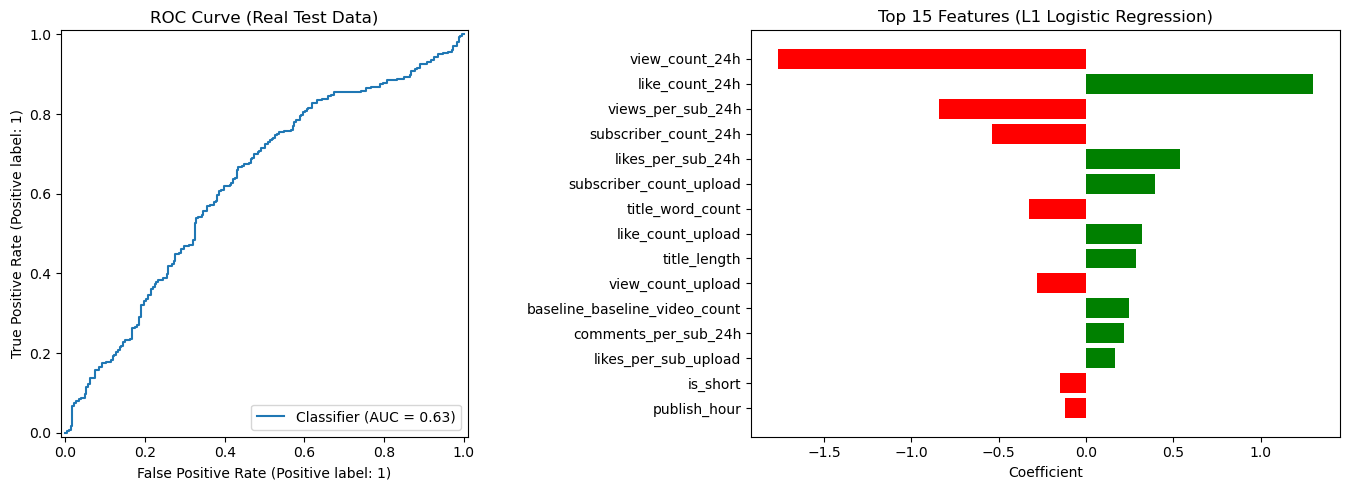

In [26]:
# === Visualizations ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve (Real Test Data)')

# Top 15 feature coefficients
top_15 = coef_df.head(15)
colors = ['green' if c > 0 else 'red' for c in top_15['coefficient']]
axes[1].barh(top_15['feature'], top_15['coefficient'], color=colors)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Top 15 Features (L1 Logistic Regression)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Debugging

                          feature  coefficient  abs_coefficient
18  subscriber_count_velocity_24h     0.071507         0.071507
15        view_count_velocity_24h    -0.054628         0.054628
16        like_count_velocity_24h     0.033451         0.033451
17     comment_count_velocity_24h    -0.031720         0.031720
